# Notebook 1 — Análisis Exploratorio y Comparaciones Estadísticas
### Tuberculosis bovina — predicción de lesión, patrón, gravedad e intensidad de la IDTC

**Cohorte real:** `BD.csv` — 106 animales, 4 explotaciones (`Expl`).

Este notebook realiza la limpieza, el diagnóstico de datos faltantes, la descripción
univariante/bivariante con tests adecuados al tipo de variable, la corrección por
comparaciones múltiples (FDR de Benjamini–Hochberg) y el diagnóstico de desbalance.

> **Hallazgos estructurales del dataset (condicionan toda la metodología):**
> 1. **Solo 4 explotaciones** → la validación honesta es *Leave-One-Farm-Out*; la
>    confusión entre-granja es grande y la generalización a granjas nuevas es muy incierta.
> 2. **Targets condicionales:** `Patron_lesiones` solo está definido en animales con
>    lesión (NA estructural = 41 no lesionados); `Score_lesional`=0 ≡ sin lesión y
>    **no existe la categoría 3** (presentes: 0,1,2,4,5).
> 3. **Predictores casi degenerados:** PIROPLASMA 86% positivo, SEXO 98F/8M, RAZA con un
>    único *Angus* (colapsado en *Otra*).
> 4. **Todas las continuas rechazan normalidad** → estadística no paramétrica.


## 1. Dependencias, reproducibilidad y carga

In [ ]:
# !pip install -q numpy pandas scipy statsmodels matplotlib seaborn
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

# Módulo compartido (debe estar en el mismo directorio que los notebooks)
import tb_utils as tb
PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

# >>> Ajusta esta ruta a tu copia local de BD.csv <<<
import os

DATA_PATH = '..\BD.csv'
print("Usando:", DATA_PATH)

raw = tb.load_raw(DATA_PATH)
df = tb.clean(raw)
print("Dimensiones:", df.shape)
df.head()

Usando: ..\BD.csv
Dimensiones: (106, 20)


,Ide,Expl,Lesiones,Localizacion,Lesiones_TB,Patron_lesiones,Score_lesional,PIROPLASMA,THEILERIA,ANAPLASMA,VITAMINA_D,CALCIO,PIROPLASMA_Q,EDAD,SEXO,RAZA,IDTC,PIROPLASMA_Q_log,RAZA2,Patron_lesiones_3
0,219743218,VC30D,Lesão caseosa,Pulmonar + linfodonos retrofaríngeos,1,1.0,4,1.0,0.0,0.0,30.095327,0.925870,4386.325854,3,F,Cruzado,23,8.386475,Cruzado,1
1,19141978,VC30D,Não apresentava lesões,Sem lesão,0,NaN,0,1.0,1.0,1.0,28.809805,0.925330,5121.251766,4,F,Cruzado,6,8.541349,Cruzado,-1
2,419913399,VC30D,Lesão,Linfonodos retrofaríngeos,1,0.0,1,0.0,0.0,1.0,16.124517,0.916724,0.000000,3,F,Cruzado,18,0.000000,Cruzado,0
3,314429794,VC30D,Lesão caseosa,Linfonodos mediastinicos,1,0.0,2,1.0,0.0,1.0,25.561307,0.907463,3869.100402,11,F,Cruzado,23,8.261036,Cruzado,0
4,17717137,VC30D,Não apresentava lesões,Sem lesão,0,NaN,0,1.0,0.0,1.0,17.302274,0.943350,5775.378886,6,F,Cruzado,13,8.661532,Cruzado,-1


## 2. Diccionario de variables y targets

| Variable | Rol | Tipo | Nota |
|---|---|---|---|
| `Expl` | grupo | nominal | Explotación/granja (4 niveles) — clave para CV agrupada |
| `Lesiones_TB` | **Target 1** | binaria | 1=lesión, 0=sin lesión |
| `Patron_lesiones` | **Target 2** | binaria | 0=localizado, 1=generalizado (**solo lesionados**) |
| `Score_lesional` | **Target 3** | ordinal | {0,1,2,4,5} (sin 3; 0=sin lesión) |
| `IDTC` | **Target 4** | recuento | 0–32, asimétrica,  intradermotuberculinización comparada (la prueba comparada de tuberculina intradérmica), que es la prueba diagnóstica in vivo estándar para la tuberculosis bovina. |
| `PIROPLASMA/THEILERIA/ANAPLASMA` | predictor | binaria | serología +/− |
| `VITAMINA_D, CALCIO, PIROPLASMA_Q, EDAD` | predictor | continua | `PIROPLASMA_Q` muy asimétrica → log1p |
| `SEXO, RAZA` | predictor | nominal | casi degeneradas |


In [ ]:
# Resumen de los cuatro targets
print("Target 1 — Lesiones_TB:")
print(df["Lesiones_TB"].value_counts().rename({0:"Sin lesión",1:"Con lesión"}).to_string())
print(f"  Prevalencia lesión = {df['Lesiones_TB'].mean():.3f}\n")

les = df[df.Lesiones_TB==1]
print("Target 2 — Patron_lesiones (solo lesionados, n=%d):" % len(les))
print(les["Patron_lesiones"].value_counts().rename({0:"Localizado",1:"Generalizado"}).to_string())
print(f"  Prevalencia generalizado = {les['Patron_lesiones'].mean():.3f}\n")

print("Target 3 — Score_lesional (atención: sin categoría 3):")
print(df["Score_lesional"].value_counts().sort_index().to_string(), "\n")

print("Target 4 — IDTC (recuento):")
print(df["IDTC"].describe()[["min","25%","50%","75%","max","mean"]].round(2).to_string())

Target 1 — Lesiones_TB:
Lesiones_TB
Con lesión    65
Sin lesión    41
  Prevalencia lesión = 0.613

Target 2 — Patron_lesiones (solo lesionados, n=65):
Patron_lesiones
Localizado      41
Generalizado    24
  Prevalencia generalizado = 0.369

Target 3 — Score_lesional (atención: sin categoría 3):
Score_lesional
0    41
1    23
2    16
4     8
5    18 

Target 4 — IDTC (recuento):
min      0.00
25%      7.00
50%     10.00
75%     14.00
max     32.00
mean    11.55


## 3. Estructura de grupos (explotaciones)

In [ ]:
farm_tab = (df.groupby("Expl")
            .agg(n=("Ide","size"),
                 prev_lesion=("Lesiones_TB","mean"),
                 idtc_med=("IDTC","median"))
            .round(3).sort_values("n", ascending=False))
print(farm_tab.to_string())
print("\n⚠️ Con 4 explotaciones, la varianza entre-granja domina y la validación")
print("   Leave-One-Farm-Out solo aporta 4 folds: generalización a granjas nuevas = MUY incierta.")

        n  prev_lesion  idtc_med
Expl                            
VC30D  55        0.582      10.0
VA32D  21        0.381      13.0
VC94C  16        0.938       7.0
WZ72B  14        0.714      11.5

⚠️ Con 4 explotaciones, la varianza entre-granja domina y la validación
   Leave-One-Farm-Out solo aporta 4 folds: generalización a granjas nuevas = MUY incierta.


## 4. Análisis de datos faltantes (missingness)

Estrategia justificada: **(a)** la ausencia en `Patron_lesiones` es *estructural*
(no lesionados) y se trata definiendo el subconjunto correspondiente, no imputando;
**(b)** la ausencia en serología/bioquímica (3–11 %) se maneja **dentro** de la
validación cruzada (imputación por mediana/moda en *train* + indicador de
*missingness*), nunca antes de partir los datos, para evitar fuga de información.


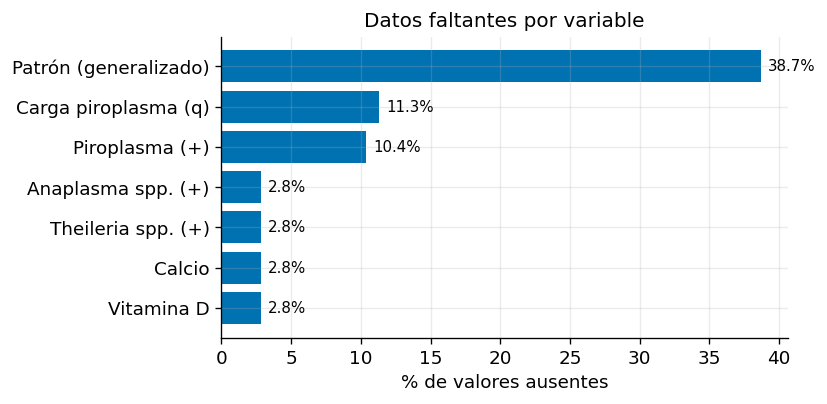

Patron NA ↔ no lesionados:
Patrón ausente  False  True 
Lesión                      
0                   0     41
1                  65      0


In [ ]:
na = df[tb.BIN_SEROLOGY+["VITAMINA_D","CALCIO","PIROPLASMA_Q","Patron_lesiones"]].isna().mean()
na = na.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7,3.5))
ax.barh(range(len(na)), na.values*100, color=PALETTE[0])
ax.set_yticks(range(len(na))); ax.set_yticklabels([tb.PRETTY.get(i,i) for i in na.index])
ax.set_xlabel("% de valores ausentes"); ax.set_title("Datos faltantes por variable")
for i,v in enumerate(na.values*100): ax.text(v+0.5,i,f"{v:.1f}%",va="center",fontsize=9)
ax.invert_yaxis(); plt.tight_layout(); plt.savefig("figures/fig1_missingness.png"); plt.show()

# ¿Es la ausencia de Patron exactamente los no lesionados?
print("Patron NA ↔ no lesionados:")
print(pd.crosstab(df.Lesiones_TB, df.Patron_lesiones.isna(),
                  rownames=["Lesión"], colnames=["Patrón ausente"]).to_string())

We are going to remove those subjects with four NAs or more in the predictive variables, and redo the missing values calculation. We also impute `Patron_lesiones = -1` for non-lesioned animals (structural NAs), creating a 3-category version: -1 = no lesion, 0 = localized, 1 = generalized.

In [ ]:

# Predictive variables where NAs can occur
pred_vars = tb.BIN_SEROLOGY + ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q"]

# Remove rows with ≥4 NAs in predictor variables
na_per_row = df[pred_vars].isna().sum(axis=1)
mask_drop = na_per_row >= 4

print(f"Rows with ≥4 NAs in predictor variables: {mask_drop.sum()}")
print(df[mask_drop][["Ide", "Expl", "Lesiones_TB"] + pred_vars].to_string())

df = df[~mask_drop].reset_index(drop=True)
print(f"\nDataset after filtering: {df.shape[0]} rows (removed {mask_drop.sum()})")

# Impute Patron_lesiones = -1 for non-lesioned animals (structural NAs)
# Result: -1 = no lesion, 0 = localized, 1 = generalized
df["Patron_lesiones"] = df["Patron_lesiones"].fillna(-1).astype(int)
print("\nPatron_lesiones distribution after imputation:")
print(df["Patron_lesiones"].value_counts().sort_index()
      .rename({-1: "No lesión (-1)", 0: "Localizado (0)", 1: "Generalizado (1)"}).to_string())


Rows with ≥4 NAs in predictor variables: 3
           Ide   Expl  Lesiones_TB  PIROPLASMA  THEILERIA  ANAPLASMA  VITAMINA_D  CALCIO  PIROPLASMA_Q
83   523998063  VA32D            1         NaN        NaN        NaN         NaN     NaN           NaN
93    22049872  WZ72B            0         NaN        NaN        NaN         NaN     NaN           NaN
101  118873853  WZ72B            1         NaN        NaN        NaN         NaN     NaN           NaN

Dataset after filtering: 103 rows (removed 3)

Patron_lesiones distribution after imputation:
Patron_lesiones
No lesión (-1)      40
Localizado (0)      40
Generalizado (1)    23


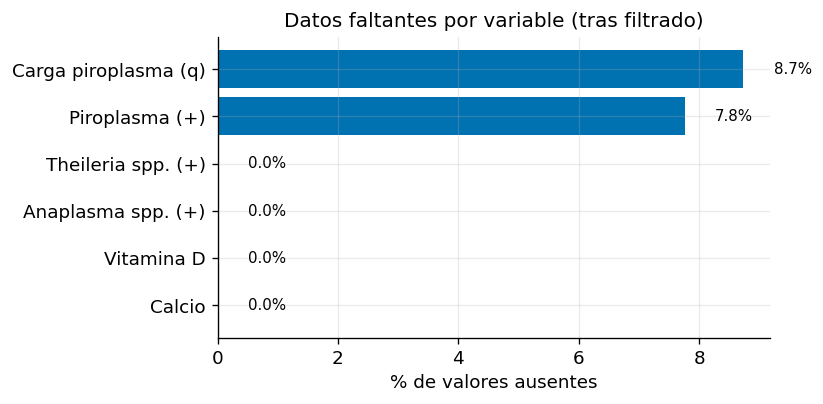

Patron_lesiones (−1=no lesión, 0=local., 1=general.) × Lesiones_TB:
Patrón  -1   0   1
Lesión            
0       40   0   0
1        0  40  23


In [ ]:

# Missingness after row filtering (Patron_lesiones now has no NAs: -1 encodes no-lesion)
na = df[tb.BIN_SEROLOGY + ["VITAMINA_D", "CALCIO", "PIROPLASMA_Q"]].isna().mean()
na = na.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(range(len(na)), na.values * 100, color=PALETTE[0])
ax.set_yticks(range(len(na))); ax.set_yticklabels([tb.PRETTY.get(i, i) for i in na.index])
ax.set_xlabel("% de valores ausentes"); ax.set_title("Datos faltantes por variable (tras filtrado)")
for i, v in enumerate(na.values * 100): ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
ax.invert_yaxis(); plt.tight_layout(); plt.savefig("figures/fig1b_missingness_filtered.png"); plt.show()

print("Patron_lesiones (−1=no lesión, 0=local., 1=general.) × Lesiones_TB:")
print(pd.crosstab(df.Lesiones_TB, df.Patron_lesiones,
                  rownames=["Lesión"], colnames=["Patrón"]).to_string())


## 5. Descriptivos univariantes

In [7]:
# Continuas: normalidad (Shapiro) -> todas no normales -> mediana [IQR]
desc = []
for c in ["VITAMINA_D","CALCIO","PIROPLASMA_Q","EDAD","IDTC","Score_lesional"]:
    x = df[c].dropna()
    desc.append(dict(variable=tb.PRETTY.get(c,c), n=len(x), mediana=np.median(x),
                     IQR=f"[{np.percentile(x,25):.2f}, {np.percentile(x,75):.2f}]",
                     min=x.min(), max=x.max(), shapiro_p=stats.shapiro(x)[1]))
print(pd.DataFrame(desc).round(3).to_string(index=False))
print("\nTodas las continuas rechazan normalidad (Shapiro p<0.05) → tests no paramétricos.")

            variable   n  mediana              IQR   min       max  shapiro_p
          Vitamina D 103   18.909   [13.55, 25.46] 0.078    53.261      0.001
              Calcio 103    0.929     [0.91, 0.95] 0.687     1.003      0.000
Carga piroplasma (q)  94  575.659 [47.05, 2199.84] 0.000 17152.953      0.000
         Edad (años) 103    5.000     [3.00, 8.00] 1.000    15.000      0.000
     Intensidad IDTC 103   10.000    [7.00, 13.00] 0.000    32.000      0.000
      Score lesional 103    1.000     [0.00, 3.00] 0.000     5.000      0.000

Todas las continuas rechazan normalidad (Shapiro p<0.05) → tests no paramétricos.


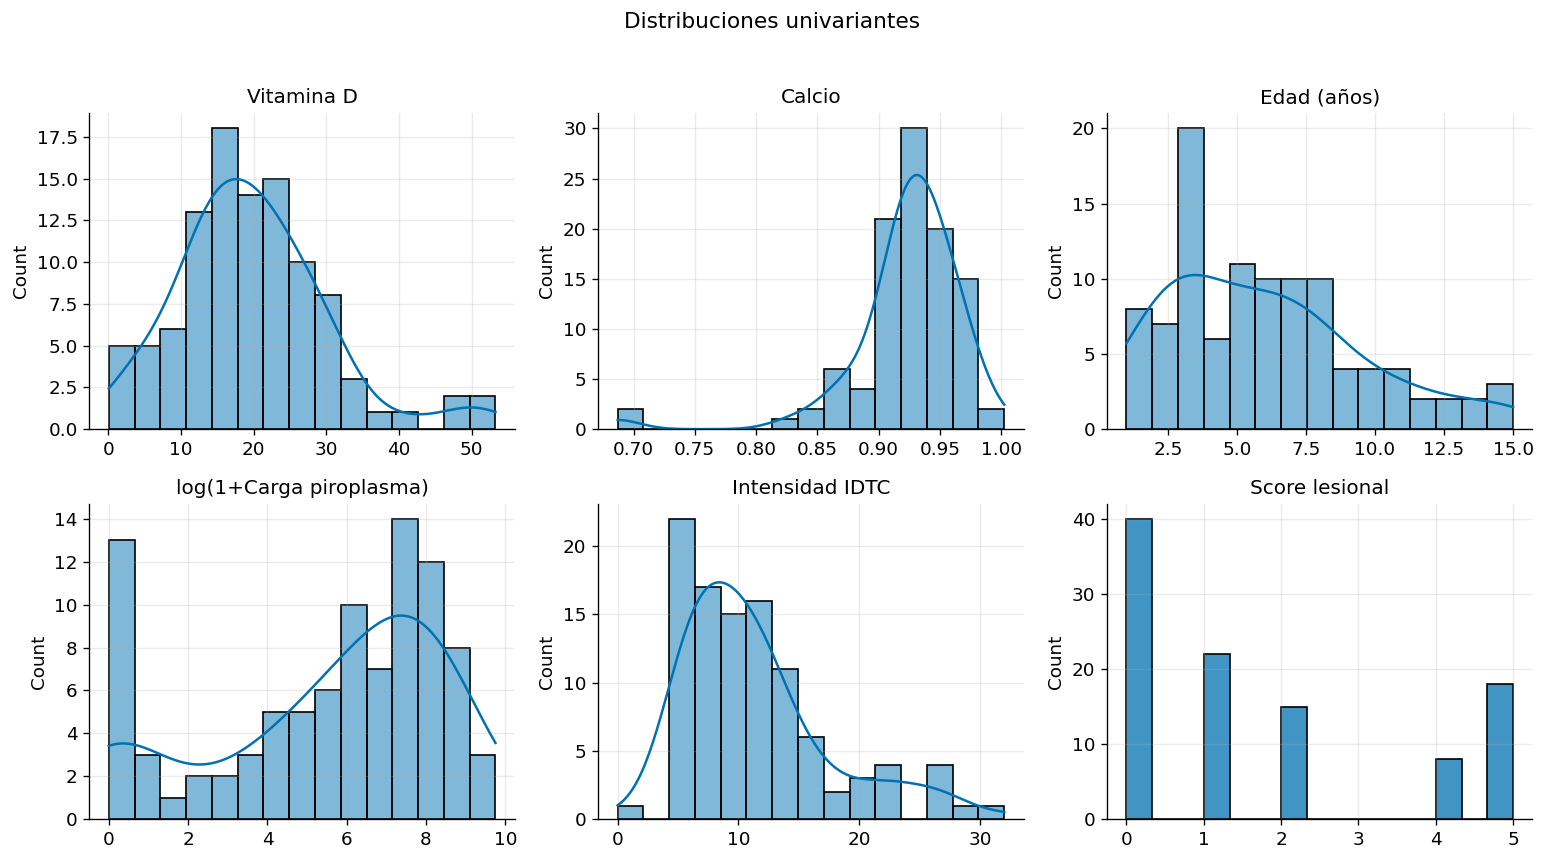

In [8]:
# Distribuciones (con log para la carga de piroplasma)
fig, axes = plt.subplots(2,3, figsize=(13,7))
for ax,c in zip(axes.ravel(), ["VITAMINA_D","CALCIO","EDAD","PIROPLASMA_Q_log","IDTC","Score_lesional"]):
    sns.histplot(df[c].dropna(), kde=(df[c].nunique()>10), color=PALETTE[0], ax=ax, bins=15)
    ax.set_title(tb.PRETTY.get(c,c)); ax.set_xlabel("")
plt.suptitle("Distribuciones univariantes", y=1.02, fontsize=13)
plt.tight_layout(); plt.savefig("figures/fig2_univariate.png"); plt.show()

## 6. Comparaciones bivariantes vs cada target

Selección de test guiada por tipo y normalidad: continuas → Mann–Whitney U
(no normales) con **Cliff's δ** e IC bootstrap de la diferencia de medianas;
binarias/nominales → Fisher (2×2 con celdas <5) o χ² con **Cramér's V**.
Corrección **FDR (Benjamini–Hochberg)** dentro de cada familia de comparaciones.


In [9]:
# --- Target 1: Lesiones_TB ---
res_les = tb.bivariate_vs_binary(df, "Lesiones_TB")
print("Lesiones_TB ~ predictores (ordenado por p):")
print(res_les.round(4).to_string(index=False))
print("\n→ Ninguna asociación sobrevive a la corrección FDR (p_fdr≈1).")

Lesiones_TB ~ predictores (ordenado por p):
        variable           test  n0  n1    med0    med1  effect effect_type  ci_low  ci_high      p  p_fdr
            EDAD Mann-Whitney U  40  63  5.0000  6.0000  0.1782     Cliff δ -1.0000   3.5000 0.1272 0.9994
      VITAMINA_D Mann-Whitney U  40  63 20.0033 18.7485 -0.1063     Cliff δ -7.6922   4.1851 0.3663 0.9994
       ANAPLASMA           Chi²  40  63     NaN     NaN  0.1029    Cramér V     NaN      NaN 0.3996 0.9994
           RAZA2           Chi²  40  63     NaN     NaN  0.1255    Cramér V     NaN      NaN 0.4442 0.9994
PIROPLASMA_Q_log Mann-Whitney U  36  58  6.1110  6.4395 -0.0283     Cliff δ -1.4395   1.7360 0.8214 1.0000
          CALCIO Mann-Whitney U  40  63  0.9268  0.9299  0.0190     Cliff δ -0.0170   0.0183 0.8737 1.0000
       THEILERIA           Chi²  40  63     NaN     NaN  0.0247    Cramér V     NaN      NaN 0.9746 1.0000
      PIROPLASMA           Chi²  36  59     NaN     NaN  0.0047    Cramér V     NaN      NaN 1.0000 

In [10]:
# --- Target 2: Patron_lesiones (solo lesionados) ---
sub_pat = tb.target_subset(df, "Patron_lesiones")
res_pat = tb.bivariate_vs_binary(sub_pat, "Patron_lesiones")
print(f"Patron_lesiones ~ predictores (n={len(sub_pat)}):")
print(res_pat.round(4).to_string(index=False))

# --- Target 2b: Patron_lesiones_3 (3 clases) ---
sub_pat3 = tb.target_subset(df, "Patron_lesiones_3")
res_pat3 = tb.bivariate_vs_multiclass(sub_pat3, "Patron_lesiones_3")
print(f"Patron_lesiones_3 ~ predictores (n={len(sub_pat3)}):\n")
print(res_pat3.round(4).to_string(index=False) if len(res_pat3) else "Ningún predictor alcanzó la muestra mínima.")


Patron_lesiones ~ predictores (n=63):
        variable           test  n0  n1    med0    med1  effect effect_type  ci_low  ci_high      p  p_fdr
PIROPLASMA_Q_log Mann-Whitney U  36  22  6.8852  4.9703 -0.3106     Cliff δ -3.8563   0.2009 0.0494 0.3553
            SEXO   Fisher exact  40  23     NaN     NaN  0.2082    Cramér V     NaN      NaN 0.1338 0.3553
       THEILERIA   Fisher exact  40  23     NaN     NaN  0.2109    Cramér V     NaN      NaN 0.1533 0.3553
           RAZA2           Chi²  40  23     NaN     NaN  0.2199    Cramér V     NaN      NaN 0.1579 0.3553
            EDAD Mann-Whitney U  40  23  7.0000  5.0000 -0.1641     Cliff δ -4.0000   1.5000 0.2803 0.5046
      VITAMINA_D        Welch t  40  23 18.6277 18.7485 -0.0283     Cliff δ -5.0795   4.5620 0.5969 0.8954
       ANAPLASMA           Chi²  40  23     NaN     NaN  0.0811    Cramér V     NaN      NaN 0.7037 0.9047
          CALCIO Mann-Whitney U  40  23  0.9297  0.9304  0.0011     Cliff δ -0.0179   0.0160 1.0000 1.0000

In [11]:
# --- Target 3: Score_lesional (ordinal) y Target 4: IDTC (recuento) → Spearman ---
preds = ["VITAMINA_D","CALCIO","PIROPLASMA_Q_log","EDAD"]
print("Score_lesional ~ continuas (Spearman):")
print(tb.spearman_table(df, "Score_lesional", preds).round(4).to_string(index=False))
print("\nIDTC ~ continuas (Spearman):")
print(tb.spearman_table(df, "IDTC", preds).round(4).to_string(index=False))

Score_lesional ~ continuas (Spearman):
        variable     rho   n  ci_low  ci_high      p  p_fdr
            EDAD  0.1396 103 -0.0628   0.3201 0.1595 0.3726
PIROPLASMA_Q_log -0.1375  94 -0.3280   0.0555 0.1863 0.3726
      VITAMINA_D -0.0787 103 -0.2642   0.1217 0.4296 0.5729
          CALCIO  0.0105 103 -0.1995   0.2221 0.9158 0.9158

IDTC ~ continuas (Spearman):
        variable     rho   n  ci_low  ci_high      p  p_fdr
      VITAMINA_D -0.1387 103 -0.3305   0.0647 0.1624 0.5745
PIROPLASMA_Q_log  0.0663  94 -0.1528   0.2937 0.5254 0.5745
          CALCIO -0.0607 103 -0.2601   0.1416 0.5425 0.5745
            EDAD -0.0560 103 -0.2291   0.1353 0.5745 0.5745


In [12]:
# IDTC por categorías (Kruskal-Wallis + post-hoc) — replica el análisis previo en R
from scipy.stats import kruskal
for c in ["THEILERIA","ANAPLASMA","PIROPLASMA","RAZA2"]:
    groups = [g["IDTC"].dropna().values for _,g in df.groupby(c)]
    groups = [g for g in groups if len(g)>0]
    if len(groups)>=2:
        H,p = kruskal(*groups)
        print(f"IDTC ~ {tb.PRETTY.get(c,c):20s}: Kruskal H={H:.2f}, p={p:.3f}")

IDTC ~ Theileria spp. (+)  : Kruskal H=1.23, p=0.268
IDTC ~ Anaplasma spp. (+)  : Kruskal H=0.21, p=0.650
IDTC ~ Piroplasma (+)      : Kruskal H=2.30, p=0.130
IDTC ~ Raza                : Kruskal H=5.90, p=0.052


## 7. Visualizaciones bivariantes (publication-ready)

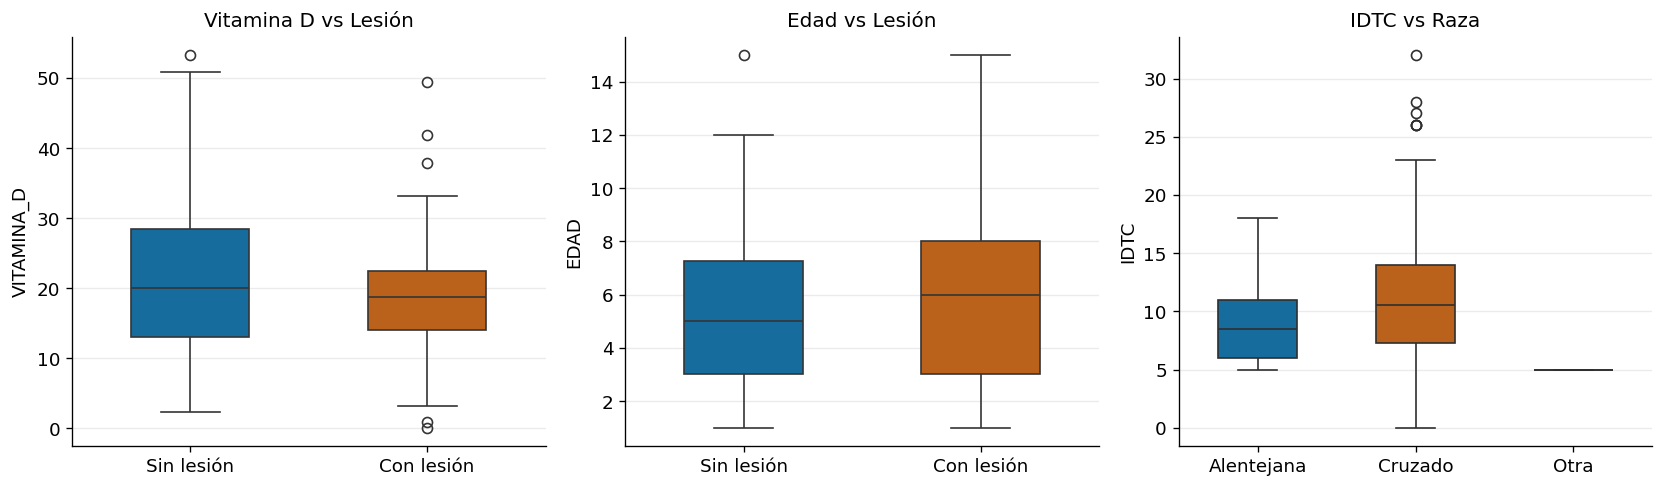

In [13]:
fig, axes = plt.subplots(1,3, figsize=(14,4.2))
sns.boxplot(data=df, x="Lesiones_TB", y="VITAMINA_D", ax=axes[0], palette=PALETTE[:2], width=.5)
axes[0].set_xticklabels(["Sin lesión","Con lesión"]); axes[0].set_title("Vitamina D vs Lesión")
sns.boxplot(data=df, x="Lesiones_TB", y="EDAD", ax=axes[1], palette=PALETTE[:2], width=.5)
axes[1].set_xticklabels(["Sin lesión","Con lesión"]); axes[1].set_title("Edad vs Lesión")
sns.boxplot(data=df, x="RAZA2", y="IDTC", ax=axes[2], palette=PALETTE, width=.5)
axes[2].set_title("IDTC vs Raza")
for a in axes: a.set_xlabel("")
plt.tight_layout(); plt.savefig("figures/fig3_bivariate.png"); plt.show()

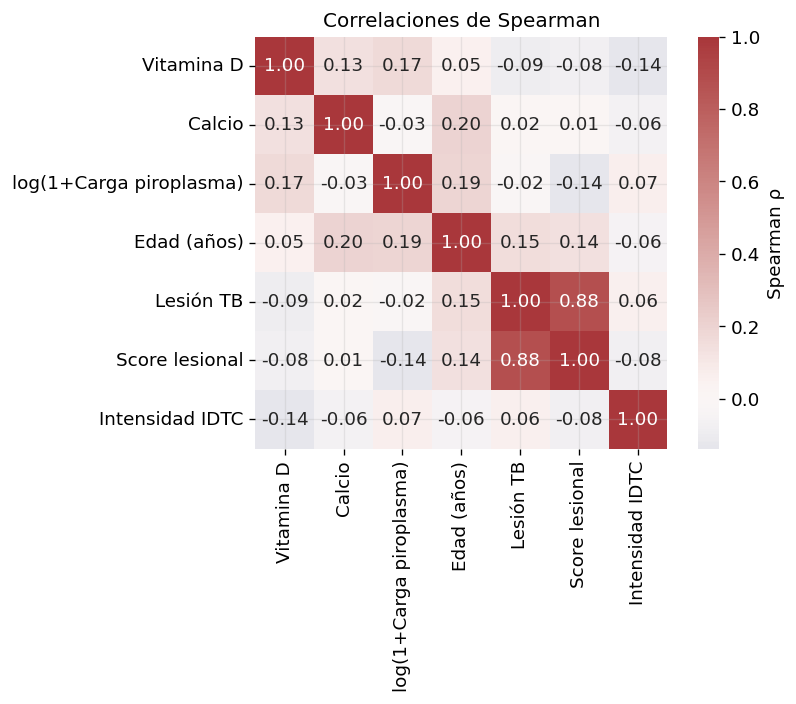

In [14]:
# Matriz de correlación de Spearman entre predictores + targets numéricos
numcols = ["VITAMINA_D","CALCIO","PIROPLASMA_Q_log","EDAD","Lesiones_TB","Score_lesional","IDTC"]
corr = df[numcols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(7.5,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True,
            cbar_kws={"label":"Spearman ρ"}, ax=ax,
            xticklabels=[tb.PRETTY.get(c,c) for c in numcols],
            yticklabels=[tb.PRETTY.get(c,c) for c in numcols])
ax.set_title("Correlaciones de Spearman"); plt.tight_layout()
plt.savefig("figures/fig4_corr.png"); plt.show()

## 8. Diagnóstico de desbalance y métricas recomendadas

Prevalencia de lesión ≈ 0.61 (desbalance leve). Con *n* pequeño y 4 granjas:
- **No** usar accuracy. Reportar **PR-AUC** (línea base = prevalencia), **ROC-AUC**,
  **Brier score** (calibración), **MCC** y **sensibilidad/especificidad** en puntos
  operativos clínicos.
- **Evitar SMOTE/undersampling**: con *n*=106 introducen ruido y fuga; preferir
  `class_weight="balanced"`.


In [15]:
prev = df["Lesiones_TB"].mean()
print(f"Prevalencia (línea base PR-AUC) = {prev:.3f}")
print(f"Prevalencia generalizado | lesión = {df[df.Lesiones_TB==1]['Patron_lesiones'].mean():.3f}")
print("Métricas primarias: PR-AUC, ROC-AUC, Brier, MCC, Sens/Spec@umbral clínico.")

Prevalencia (línea base PR-AUC) = 0.612
Prevalencia generalizado | lesión = 0.365
Métricas primarias: PR-AUC, ROC-AUC, Brier, MCC, Sens/Spec@umbral clínico.


## 9. Exportar dataset limpio para los Notebooks 2 y 3

In [17]:
# CSV portable (las dtypes se re-derivan con tb.clean en los siguientes notebooks)
df.to_csv("../bd_clean.csv", index=False)
print("Guardado: ../bd_clean.csv  →", df.shape)

Guardado: ../bd_clean.csv  → (103, 20)


## 10. Conclusiones del EDA

- **Ningún predictor** muestra asociación significativa con la lesión tras corrección FDR.
- Las señales bivariantes más fuertes (edad–IDTC, calcio–IDTC) son **débiles** y deben
  validarse fuera de muestra (Notebook 2).
- La estructura de **4 granjas** y los **targets condicionales** son las limitaciones
  dominantes y guían la validación agrupada y la cuantificación de incertidumbre.
